<a href="https://colab.research.google.com/github/larissaorsomarso/mvp-cep-concreto/blob/main/MVP_CEP_Concreto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scipy --quiet

# ==============================================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==============================================================================

# --- MANIPULAÇÃO DE DADOS ---
import pandas as pd
# pandas: a biblioteca principal para trabalhar com tabelas (DataFrames) em Python.
# Usamos para carregar o dataset, renomear colunas, filtrar linhas e criar novas colunas.

import numpy as np
# numpy: fornece operações matemáticas vetorizadas (médias, desvios, raízes, etc.).
# Essencial para calcular os limites das cartas de controle e índices de capacidade.

# --- VISUALIZAÇÃO ---
import matplotlib.pyplot as plt
# matplotlib: biblioteca base de gráficos em Python. Usamos para criar todos os
# gráficos do projeto (cartas de controle, histogramas, curva ROC, etc.)

import seaborn as sns
# seaborn: construída em cima do matplotlib, facilita gráficos estatísticos mais
# elaborados com menos código (heatmaps de correlação, boxplots, etc.)

# --- ESTATÍSTICA ---
from scipy import stats
# scipy.stats: fornece testes estatísticos prontos.
# Usamos o Shapiro-Wilk (stats.shapiro) para testar se os dados seguem
# distribuição normal — condição importante para o CEP.

# --- PRÉ-PROCESSAMENTO ---
from sklearn.preprocessing import StandardScaler
# StandardScaler: padroniza as variáveis para média=0 e desvio padrão=1.
# JUSTIFICATIVA: A Regressão Logística é sensível à escala das variáveis.
# Se cimento (kg/m³ ~300) e superplastificante (kg/m³ ~6) estiverem em escalas
# muito diferentes, o modelo pode ignorar variáveis com valores menores.
# Random Forest e Gradient Boosting NÃO precisam de escalonamento, mas
# padronizamos de qualquer forma para poder comparar todos os modelos de forma justa.

from sklearn.model_selection import (
    train_test_split,    # Divide os dados em treino e teste
    StratifiedKFold,     # Validação cruzada que mantém proporção entre classes
    RandomizedSearchCV,  # Busca de hiperparâmetros (mais eficiente que GridSearch)
    cross_val_score      # Avalia modelo com validação cruzada simples
)
# JUSTIFICATIVA DE RandomizedSearchCV vs GridSearchCV:
# GridSearchCV testa TODAS as combinações possíveis de hiperparâmetros.
# RandomizedSearchCV testa uma amostra aleatória — muito mais rápido e com
# resultados estatisticamente equivalentes. Com datasets pequenos como o nosso, a diferença de qualidade é desprezível.

# --- MODELOS DE MACHINE LEARNING ---
from sklearn.tree import DecisionTreeClassifier
# Árvore de Decisão: modelo baseline (ponto de partida simples).
# JUSTIFICATIVA: interpretável, fácil de visualizar, não precisa de escalonamento.

from sklearn.linear_model import LogisticRegression
# Regressão Logística: segundo baseline, modelo linear.
# JUSTIFICATIVA: apesar do nome "regressão", resolve classificação binária.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# Random Forest: conjunto de árvores de decisão que votam juntas.
# JUSTIFICATIVA: robusto contra overfitting, lida bem com variáveis correlacionadas
# (cimento e resistência têm correlação alta), e produz feature importance.

# Gradient Boosting: árvores construídas sequencialmente, cada uma corrigindo
# os erros da anterior.
# JUSTIFICATIVA: geralmente o mais preciso entre modelos clássicos. O checklist
# pede "método avançado ou mais complexo" — este é ele.

# --- MÉTRICAS DE AVALIAÇÃO ---
from sklearn.metrics import (
    classification_report,  # Relatório completo: precision, recall, F1 por classe
    accuracy_score,          # Acurácia (% de acertos totais)
    confusion_matrix,        # Matriz de confusão (verdadeiros/falsos positivos e negativos)
    roc_auc_score,           # Área sob a curva ROC (melhor métrica para classes desbalanceadas)
    roc_curve,               # Pontos da curva ROC para plotar o gráfico
    f1_score                 # F1-score: média harmônica entre precision e recall
)
# JUSTIFICATIVA DAS MÉTRICAS:
# Acurácia SOZINHA é enganosa quando as classes são desbalanceadas.
# Ex: se 70% dos concretos são "comuns", um modelo que chute SEMPRE "comum"
# acerta 70% sem aprender nada.
# F1-score ponderado e ROC-AUC equilibram acertos entre as duas classes.

import warnings
warnings.filterwarnings('ignore')
# Suprimimos avisos não críticos para manter a saída do notebook limpa.

import time
# time: usamos para medir o tempo de treinamento de cada modelo.

print("=" * 60)
print("  BIBLIOTECAS IMPORTADAS COM SUCESSO")
print("=" * 60)
print(f"  pandas   {pd.__version__}  — manipulação de dados")
print(f"  numpy    {np.__version__}  — cálculos matemáticos")
print(f"  sklearn  — modelos e métricas de ML")
print(f"  scipy    — testes estatísticos (Shapiro-Wilk)")
print("=" * 60)

  BIBLIOTECAS IMPORTADAS COM SUCESSO
  pandas   2.2.2  — manipulação de dados
  numpy    2.0.2  — cálculos matemáticos
  sklearn  — modelos e métricas de ML
  scipy    — testes estatísticos (Shapiro-Wilk)


In [5]:
# ==============================================================================
# "Definição do Problema"
# "Qual é a descrição do problema?"
# "Descreva o seu dataset (atributos, etc.)"
# "Que restrições ou condições foram impostas para selecionar os dados?"
# ==============================================================================

# --- CARREGAMENTO DO DATASET ---
# Usamos o dataset "Concrete Compressive Strength" do UCI Machine Learning Repository.
# JUSTIFICATIVA DA ESCOLHA DO DATASET:
# 1. É um problema real de engenharia civil — avaliar qualidade de produção de concreto.
# 2. Tem variáveis contínuas (ideais para CEP) e uma saída numérica que podemos
#    transformar em classificação binária.
# 3. Possui 1030 registros — suficiente para ML.
# 4. Zero valores faltantes — não precisamos imputar dados.

URL_DATASET = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
# O arquivo original é .xls (Excel antigo), por isso usamos read_excel.
# A biblioteca 'xlrd' é necessária internamente pelo pandas para ler .xls.

try:
    df_original = pd.read_excel(URL_DATASET)
    print("Dataset carregado com sucesso do repositório UCI!")
except Exception as e:
    print(f"Erro ao carregar do UCI. Tentando fonte alternativa... Erro: {e}")
    # Fonte alternativa caso o UCI esteja fora do ar
    URL_ALT = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Concrete_Data.csv"
    df_original = pd.read_csv(URL_ALT)
    print("Dataset carregado da fonte alternativa!")

# --- RENOMEAÇÃO DAS COLUNAS ---
# O dataset original tem colunas com nomes longos e em inglês.
# Renomeamos para nomes curtos em português — mais fácil de usar no código
# e mais claro na apresentação ao professor.

nomes_colunas = {
    df_original.columns[0]: 'cimento',           # kg/m³ — ligante principal
    df_original.columns[1]: 'escoria',            # kg/m³ — subproduto industrial, substitui parte do cimento
    df_original.columns[2]: 'cinza_volante',      # kg/m³ — resíduo de usinas termoelétricas, melhora durabilidade
    df_original.columns[3]: 'agua',               # kg/m³ — ativa a hidratação do cimento
    df_original.columns[4]: 'superplastificante', # kg/m³ — aditivo que aumenta trabalhabilidade sem mais água
    df_original.columns[5]: 'agregado_graudo',    # kg/m³ — brita, esqueleto do concreto
    df_original.columns[6]: 'agregado_miudo',     # kg/m³ — areia, preenche os vazios
    df_original.columns[7]: 'idade_dias',         # dias — tempo de cura (hidratação = resistência)
    df_original.columns[8]: 'resistencia_mpa'     # MPa — variável alvo: resistência à compressão
}

df = df_original.rename(columns=nomes_colunas).copy()
# .copy() cria uma cópia independente — boa prática para não modificar o df original acidentalmente.

print("\n--- PRIMEIRAS 5 LINHAS DO DATASET ---")
print(df.head())

print("\n--- INFORMAÇÕES GERAIS DO DATASET ---")
print(f"  Total de registros  : {df.shape[0]}")
print(f"  Total de variáveis  : {df.shape[1]}")
print(f"  Variável alvo       : resistencia_mpa")
print(f"  Variáveis preditoras: {df.shape[1] - 1}")
print(f"  Valores faltantes   : {df.isnull().sum().sum()} (zero — dataset limpo)")
print(f"  Registros duplicados: {df.duplicated().sum()}")

Dataset carregado com sucesso do repositório UCI!

--- PRIMEIRAS 5 LINHAS DO DATASET ---
   cimento  escoria  cinza_volante   agua  superplastificante  \
0    540.0      0.0            0.0  162.0                 2.5   
1    540.0      0.0            0.0  162.0                 2.5   
2    332.5    142.5            0.0  228.0                 0.0   
3    332.5    142.5            0.0  228.0                 0.0   
4    198.6    132.4            0.0  192.0                 0.0   

   agregado_graudo  agregado_miudo  idade_dias  resistencia_mpa  
0           1040.0           676.0          28        79.986111  
1           1055.0           676.0          28        61.887366  
2            932.0           594.0         270        40.269535  
3            932.0           594.0         365        41.052780  
4            978.4           825.5         360        44.296075  

--- INFORMAÇÕES GERAIS DO DATASET ---
  Total de registros  : 1030
  Total de variáveis  : 9
  Variável alvo       : resist

In [ ]:
# BLOCO 3: ESTATÍSTICAS DESCRITIVAS COMPLETAS

print("=" * 55)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 55)

# 3.1 — Tabela completa com medidas além do describe() padrão
desc = df_raw.describe().T  # .T = transposta, mais legível
desc["cv%"] = (desc["std"] / desc["mean"] * 100).round(2)   # coeficiente de variação
desc["mediana"] = df_raw.median()
desc["amplitude"] = desc["max"] - desc["min"]

# Selecionando e ordenando as colunas que importam
desc_final = desc[["count", "mean", "mediana", "std", "cv%",
                    "min", "25%", "75%", "max", "amplitude"]]
desc_final.columns = ["N", "Média", "Mediana", "DP", "CV%",
                       "Mín", "Q1", "Q3", "Máx", "Amplitude"]

print(desc_final.round(2).to_string())

# 3.2 — Foco na variável-chave: resistência
r = df_raw["resistencia"]
print("\n--- Indicadores adicionais: Resistência (MPa) ---")
print(f"  Assimetria (skewness):  {r.skew():.3f}")
print(f"  Curtose:                {r.kurt():.3f}")
print(f"  % acima de 40 MPa:      {(r >= 40).mean()*100:.1f}%")
print(f"  % abaixo de 40 MPa:     {(r < 40).mean()*100:.1f}%")

ESTATÍSTICAS DESCRITIVAS
                         N   Média  Mediana      DP     CV%     Mín      Q1       Q3     Máx  Amplitude
cimento             1030.0  281.17   272.90  104.51   37.17  102.00  192.38   350.00   540.0     438.00
escoria             1030.0   73.90    22.00   86.28  116.76    0.00    0.00   142.95   359.4     359.40
cinza_volante       1030.0   54.19     0.00   64.00  118.10    0.00    0.00   118.27   200.1     200.10
agua                1030.0  181.57   185.00   21.36   11.76  121.75  164.90   192.00   247.0     125.25
superplastificante  1030.0    6.20     6.35    5.97   96.30    0.00    0.00    10.16    32.2      32.20
agregado_graudo     1030.0  972.92   968.00   77.75    7.99  801.00  932.00  1029.40  1145.0     344.00
agregado_miudo      1030.0  773.58   779.51   80.18   10.36  594.00  730.95   824.00   992.6     398.60
idade               1030.0   45.66    28.00   63.17  138.34    1.00    7.00    56.00   365.0     364.00
resistencia         1030.0   35.82    3

MATRIZ DE CORRELAÇÃO

Correlação de cada variável com a RESISTÊNCIA:
  cimento                +0.498  ↑  (moderada)
  superplastificante     +0.366  ↑  (moderada)
  idade                  +0.329  ↑  (moderada)
  escoria                +0.135  ↑  (fraca)
  cinza_volante          -0.106  ↓  (fraca)
  agregado_graudo        -0.165  ↓  (fraca)
  agregado_miudo         -0.167  ↓  (fraca)
  agua                   -0.290  ↓  (fraca)


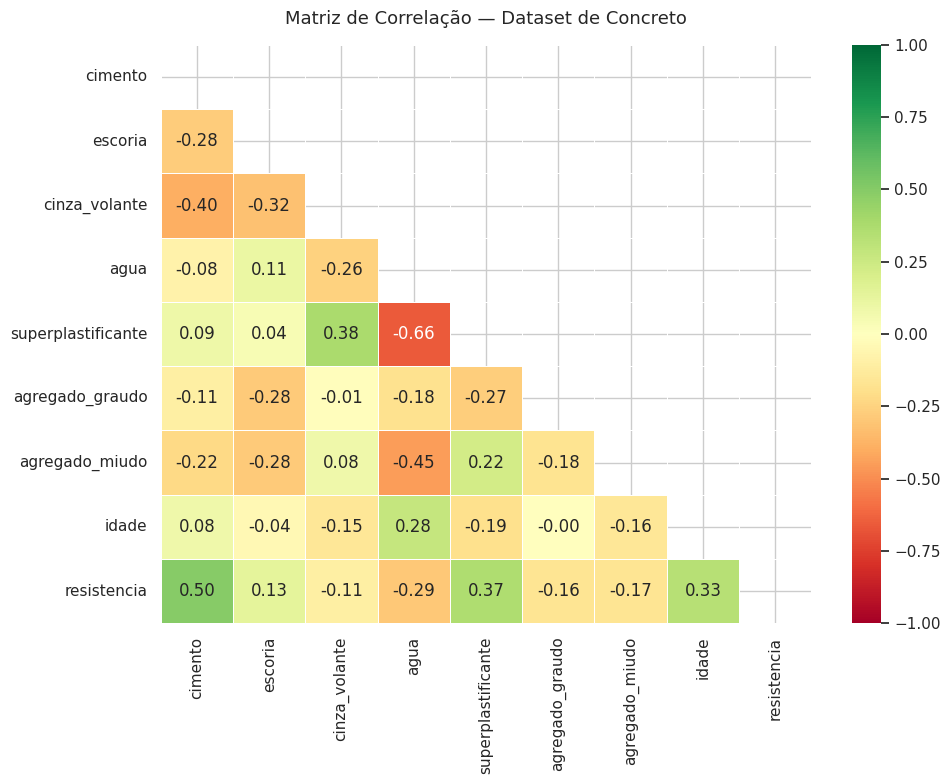

  → Figura salva: correlacoes.png


In [ ]:
# BLOCO 4: ANÁLISE DE CORRELAÇÕES

print("=" * 55)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 55)

correlacoes = df_raw.corr(numeric_only=True)

# 4.1 — Exibindo correlações com a resistência, ordenadas
cor_resist = (correlacoes["resistencia"]
              .drop("resistencia")
              .sort_values(ascending=False))

print("\nCorrelação de cada variável com a RESISTÊNCIA:")
for var, val in cor_resist.items():
    sinal = "↑" if val > 0 else "↓"
    forca = "forte" if abs(val) > 0.5 else ("moderada" if abs(val) > 0.3 else "fraca")
    print(f"  {var:<22} {val:+.3f}  {sinal}  ({forca})")

# 4.2 — Heatmap visual
fig, ax = plt.subplots(figsize=(10, 8))

mascara = np.triu(np.ones_like(correlacoes, dtype=bool))  # mostra só metade

sns.heatmap(
    correlacoes,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlação — Dataset de Concreto", pad=15)
plt.tight_layout()
plt.savefig("correlacoes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: correlacoes.png")

ANÁLISE DE DISTRIBUIÇÃO E NORMALIDADE

Teste de Shapiro-Wilk (H0: distribuição normal):
  Variável                 W-stat    p-valor   Normal?
  ----------------------------------------------------
  cimento                  0.9590     0.0000       Não
  escoria                  0.8124     0.0000       Não
  cinza_volante            0.7620     0.0000       Não
  agua                     0.9804     0.0000       Não
  superplastificante       0.8660     0.0000       Não
  agregado_graudo          0.9825     0.0000       Não
  agregado_miudo           0.9807     0.0000       Não
  idade                    0.5907     0.0000       Não
  resistencia              0.9798     0.0000       Não


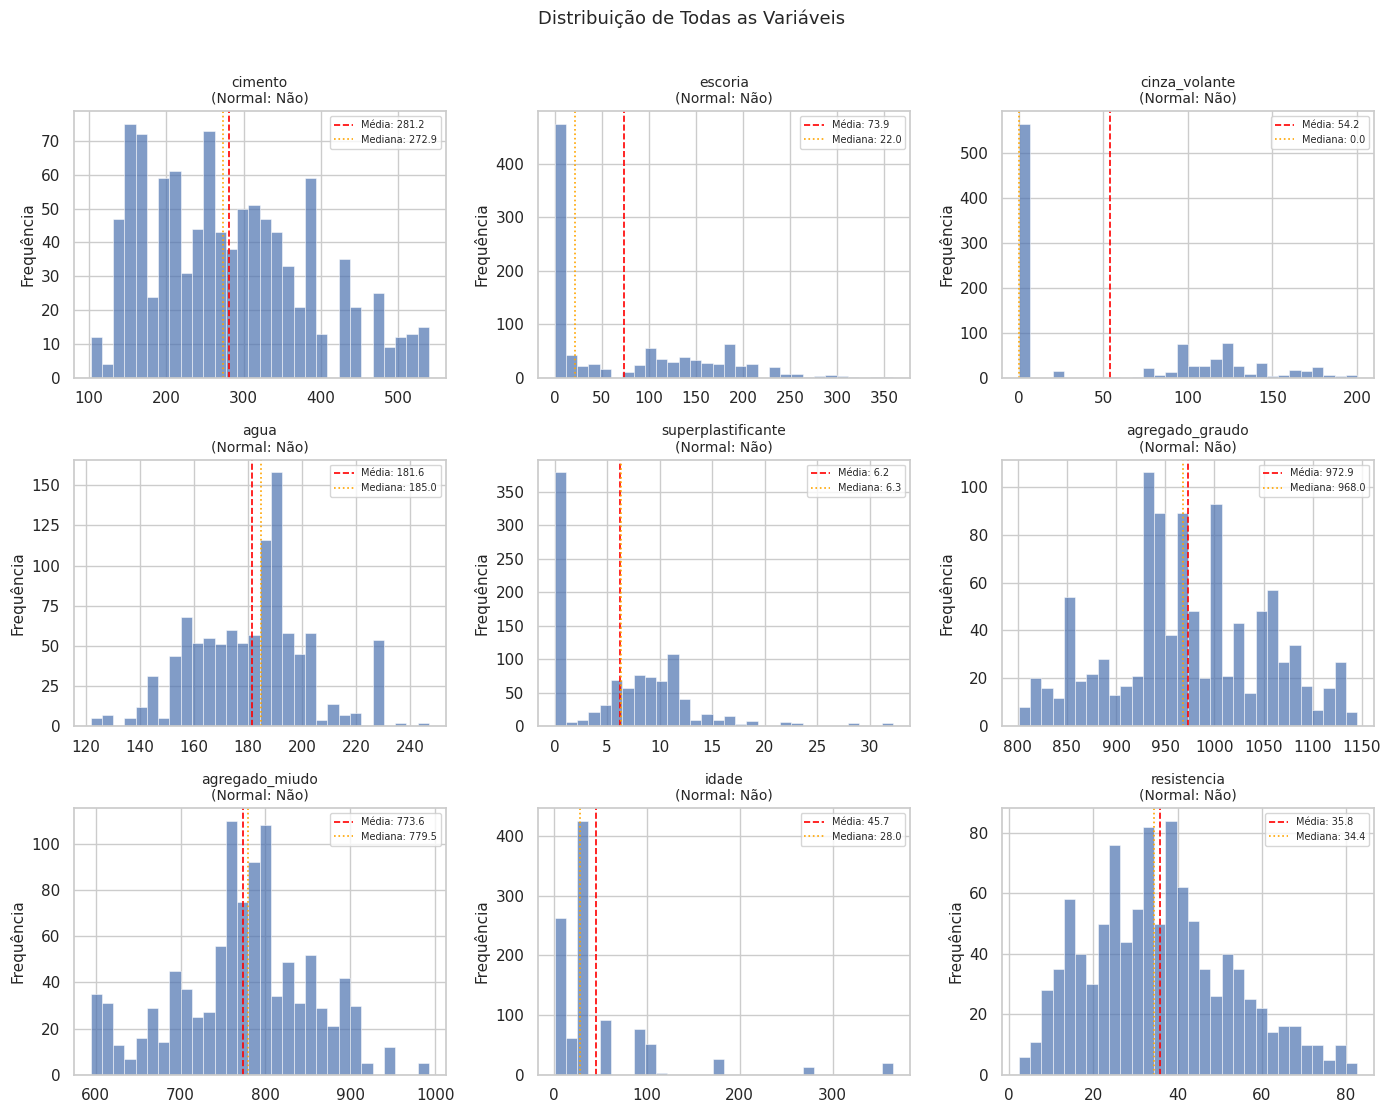

  → Figura salva: distribuicoes.png


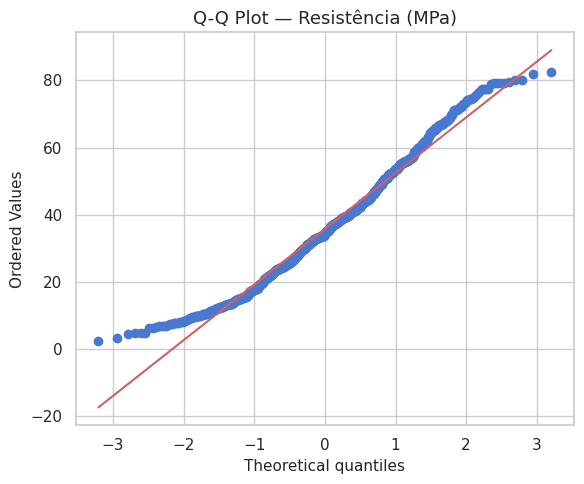

  → Figura salva: qqplot_resistencia.png


In [ ]:
# BLOCO 5: DISTRIBUIÇÃO E TESTE DE NORMALIDADE

print("=" * 55)
print("ANÁLISE DE DISTRIBUIÇÃO E NORMALIDADE")
print("=" * 55)

variaveis = df_raw.columns.tolist()

# 5.1 — Teste de Shapiro-Wilk para cada variável
# (usa amostra de 50 por limitação do teste para n > 5000)
print("\nTeste de Shapiro-Wilk (H0: distribuição normal):")
print(f"  {'Variável':<22} {'W-stat':>8}  {'p-valor':>9}  {'Normal?':>8}")
print("  " + "-" * 52)

resultados_normalidade = {}
for col in variaveis:
    amostra = df_raw[col].dropna()
    if len(amostra) > 5000:
        amostra = amostra.sample(5000, random_state=42)
    stat, p = stats.shapiro(amostra)
    normal = "Sim" if p > 0.05 else "Não"
    resultados_normalidade[col] = {"stat": stat, "p": p, "normal": normal}
    print(f"  {col:<22} {stat:>8.4f}  {p:>9.4f}  {normal:>8}")

# 5.2 — Visualização: histogramas + Q-Q plot da resistência
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    ax = axes[i]
    dados = df_raw[col].dropna()

    ax.hist(dados, bins=30, color="#4C72B0", alpha=0.7,
            edgecolor="white", linewidth=0.5)
    ax.axvline(dados.mean(), color="red",
               linestyle="--", linewidth=1.2, label=f"Média: {dados.mean():.1f}")
    ax.axvline(dados.median(), color="orange",
               linestyle=":", linewidth=1.2, label=f"Mediana: {dados.median():.1f}")

    normal_str = resultados_normalidade[col]["normal"]
    ax.set_title(f"{col}\n(Normal: {normal_str})", fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel("Frequência")

plt.suptitle("Distribuição de Todas as Variáveis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("distribuicoes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: distribuicoes.png")

# 5.3 — Q-Q plot específico para resistência (importante para CEP)
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(df_raw["resistencia"], dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Resistência (MPa)")
plt.tight_layout()
plt.savefig("qqplot_resistencia.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: qqplot_resistencia.png")

VARIÁVEL ALVO E BALANCEAMENTO

  Limiar adotado: 40 MPa

  Classe                         N        %
  ----------------------------------------
  Comum (< 40 MPa)             651    63.2%
  Alta Res. (≥ 40 MPa)         379    36.8%

  Razão Alta/Comum: 0.58
  ✔ Dataset razoavelmente balanceado.


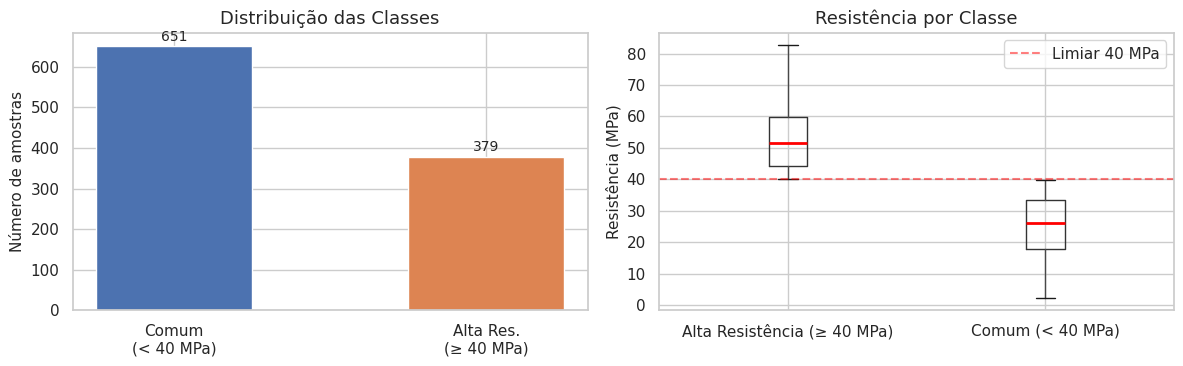

  → Figura salva: balanceamento_classes.png


In [ ]:
# BLOCO 6: VARIÁVEL ALVO E BALANCEAMENTO DAS CLASSES

print("=" * 55)
print("VARIÁVEL ALVO E BALANCEAMENTO")
print("=" * 55)

# Criando a variável binária (limiar 40 MPa)
LIMIAR_MPa = 40
df_raw["categoria"] = (df_raw["resistencia"] >= LIMIAR_MPa).astype(int)
df_raw["categoria_label"] = df_raw["categoria"].map(
    {0: "Comum (< 40 MPa)", 1: "Alta Resistência (≥ 40 MPa)"}
)

# Contagem e proporção
contagem = df_raw["categoria"].value_counts().sort_index()
proporcao = df_raw["categoria"].value_counts(normalize=True).sort_index() * 100

print(f"\n  Limiar adotado: {LIMIAR_MPa} MPa")
print(f"\n  {'Classe':<25} {'N':>6}  {'%':>7}")
print("  " + "-" * 40)
for cat, n in contagem.items():
    label = "Comum (< 40 MPa)" if cat == 0 else "Alta Res. (≥ 40 MPa)"
    print(f"  {label:<25} {n:>6}  {proporcao[cat]:>6.1f}%")

razao = contagem[1] / contagem[0]
print(f"\n  Razão Alta/Comum: {razao:.2f}")
if razao < 0.5 or razao > 2.0:
    print("  ⚠ Dataset desbalanceado — considerar SMOTE ou pesos nas Partes 3 e 4.")
else:
    print("  ✔ Dataset razoavelmente balanceado.")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
cores = ["#4C72B0", "#DD8452"]
axes[0].bar(["Comum\n(< 40 MPa)", "Alta Res.\n(≥ 40 MPa)"],
            contagem.values, color=cores, edgecolor="white", width=0.5)
axes[0].set_title("Distribuição das Classes")
axes[0].set_ylabel("Número de amostras")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 5, str(v), ha="center", va="bottom", fontsize=10)

# Boxplot por categoria
df_raw.boxplot(column="resistencia", by="categoria_label",
               ax=axes[1], grid=True,
               boxprops=dict(color="#333"),
               medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Resistência por Classe")
axes[1].set_xlabel("")
axes[1].set_ylabel("Resistência (MPa)")
axes[1].axhline(LIMIAR_MPa, color="red",
                linestyle="--", alpha=0.5, label=f"Limiar {LIMIAR_MPa} MPa")
axes[1].legend()
plt.suptitle("")
plt.tight_layout()
plt.savefig("balanceamento_classes.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: balanceamento_classes.png")

In [ ]:
# BLOCO 7: PREPARAÇÃO DOS DADOS PARA O CEP
# Este bloco entrega os DataFrames prontos para a Parte 2

print("=" * 55)
print("PREPARAÇÃO PARA ANÁLISE CEP")
print("=" * 55)

# 7.1 — Dataset completo limpo (sem duplicatas)
df = df_raw.drop_duplicates().copy()
n_removidos = len(df_raw) - len(df)
print(f"\n  Registros originais:  {len(df_raw)}")
print(f"  Duplicatas removidas: {n_removidos}")
print(f"  Registros finais:     {len(df)}")

# 7.2 — Dataset filtrado por idade (28 dias — padrão ABNT NBR 5739)
df_28 = df[df["idade"] == 28].copy().reset_index(drop=True)
df_28["seq_producao"] = range(1, len(df_28) + 1)  # índice de sequência temporal

print(f"\n  Amostras aos 28 dias: {len(df_28)}")
print(f"  (Estas serão usadas nas Cartas de Controle — Parte 2)")

# 7.3 — Distribuição por idade (para referência)
print("\n  Distribuição de amostras por idade (dias):")
dist_idade = df["idade"].value_counts().sort_index()
for idade, n in dist_idade.items():
    barra = "█" * (n // 5)
    print(f"  {str(idade).rjust(4)} dias: {n:>4} amostras  {barra}")

# 7.4 — Resumo final dos objetos disponíveis
print("\n" + "=" * 55)
print("OBJETOS DISPONÍVEIS PARA AS PRÓXIMAS PARTES:")
print("=" * 55)
print("  df      → Dataset completo limpo (todas as idades)")
print("  df_28   → Somente ensaios de 28 dias (para CEP)")
print(f"            Shape: {df_28.shape}")
print("  LIMIAR_MPa = 40  (limiar para classificação binária)")

PREPARAÇÃO PARA ANÁLISE CEP

  Registros originais:  1030
  Duplicatas removidas: 25
  Registros finais:     1005

  Amostras aos 28 dias: 419
  (Estas serão usadas nas Cartas de Controle — Parte 2)

  Distribuição de amostras por idade (dias):
     1 dias:    2 amostras  
     3 dias:  129 amostras  █████████████████████████
     7 dias:  122 amostras  ████████████████████████
    14 dias:   62 amostras  ████████████
    28 dias:  419 amostras  ███████████████████████████████████████████████████████████████████████████████████
    56 dias:   86 amostras  █████████████████
    90 dias:   54 amostras  ██████████
    91 dias:   17 amostras  ███
   100 dias:   52 amostras  ██████████
   120 dias:    3 amostras  
   180 dias:   26 amostras  █████
   270 dias:   13 amostras  ██
   360 dias:    6 amostras  █
   365 dias:   14 amostras  ██

OBJETOS DISPONÍVEIS PARA AS PRÓXIMAS PARTES:
  df      → Dataset completo limpo (todas as idades)
  df_28   → Somente ensaios de 28 dias (para CEP)
      

In [ ]:
# BLOCO 8: FUNÇÕES DE DETECÇÃO DE ANOMALIAS (REGRAS DE NELSON)
# Estas funções detectam violações nas cartas de controle.
# Usamos as Regras de Nelson, que são as mais adotadas em
# controle de qualidade industrial no Brasil.

def regra_1(valores, lcl, ucl):
    """Regra 1: ponto além dos limites de controle (±3σ)."""
    return [i for i, v in enumerate(valores) if v > ucl or v < lcl]

def regra_2(valores, media):
    """Regra 2: 9 pontos consecutivos no mesmo lado da média."""
    violacoes = []
    n = len(valores)
    for i in range(8, n):
        janela = valores[i-8:i+1]
        if all(v > media for v in janela) or all(v < media for v in janela):
            violacoes.append(i)
    return violacoes

def regra_3(valores):
    """Regra 3: 6 pontos consecutivos em tendência (crescente ou decrescente)."""
    violacoes = []
    n = len(valores)
    for i in range(5, n):
        janela = valores[i-5:i+1]
        crescente = all(janela[j] < janela[j+1] for j in range(5))
        decrescente = all(janela[j] > janela[j+1] for j in range(5))
        if crescente or decrescente:
            violacoes.append(i)
    return violacoes

def regra_4(valores, media, sigma):
    """Regra 4: 2 de 3 pontos consecutivos além de ±2σ (mesmo lado)."""
    violacoes = []
    n = len(valores)
    for i in range(2, n):
        janela = valores[i-2:i+1]
        acima = sum(1 for v in janela if v > media + 2*sigma)
        abaixo = sum(1 for v in janela if v < media - 2*sigma)
        if acima >= 2 or abaixo >= 2:
            violacoes.append(i)
    return violacoes

def detectar_todas_regras(valores, media, sigma, lcl, ucl):
    """Executa todas as regras e retorna um dicionário consolidado."""
    return {
        "Regra 1 — Além de ±3σ":          regra_1(valores, lcl, ucl),
        "Regra 2 — 9 pts mesmo lado":      regra_2(valores, media),
        "Regra 3 — 6 pts em tendência":    regra_3(valores),
        "Regra 4 — 2/3 pts além de ±2σ":  regra_4(valores, media, sigma),
    }

def explicar_anomalia(regra, indice, valores, media, df_ref):
    """
    Gera explicação textual de uma anomalia detectada.
    Cruza o ponto problemático com as variáveis de processo
    para ajudar na análise de causa raiz.
    """
    v = valores[indice]
    desvio = v - media
    linha = df_ref.iloc[indice]

    explicacoes = {
        "Regra 1 — Além de ±3σ": (
            f"Ponto {indice+1} com resistência {v:.1f} MPa está "
            f"{'ACIMA' if desvio > 0 else 'ABAIXO'} do limite de controle "
            f"(desvio de {abs(desvio):.1f} MPa em relação à média). "
            f"Causa possível: variação extrema em insumos críticos "
            f"(cimento={linha['cimento']:.0f} kg/m³, "
            f"água={linha['agua']:.0f} kg/m³, "
            f"a/c={linha['agua']/linha['cimento']:.2f})."
        ),
        "Regra 2 — 9 pts mesmo lado": (
            f"Ponto {indice+1} encerra sequência de 9 ou mais pontos "
            f"{'acima' if v > media else 'abaixo'} da média. "
            f"Indica mudança sistemática no processo — possível alteração "
            f"de fornecedor, dosagem ou procedimento de cura."
        ),
        "Regra 3 — 6 pts em tendência": (
            f"Ponto {indice+1} encerra tendência de 6 pontos consecutivos. "
            f"O processo está em deriva — verifique desgaste de equipamento, "
            f"variação gradual na umidade dos agregados ou na temperatura."
        ),
        "Regra 4 — 2/3 pts além de ±2σ": (
            f"Ponto {indice+1} faz parte de grupo com 2 de 3 pontos além "
            f"de ±2σ. Sinal precoce de instabilidade — o processo pode estar "
            f"próximo de uma perturbação maior."
        ),
    }
    return explicacoes.get(regra, "Anomalia detectada.")

print("✔ Funções de detecção de anomalias definidas.")
print("  Regras implementadas: 1, 2, 3 e 4 (Nelson)")

✔ Funções de detecção de anomalias definidas.
  Regras implementadas: 1, 2, 3 e 4 (Nelson)


CARTA I — RESISTÊNCIA INDIVIDUAL (28 dias)

  Parâmetros calculados:
  Média (X̄):          36.43 MPa
  Média MR (MR̄):      11.11 MPa
  Sigma estimado (σ): 9.85 MPa
  LSC (Limite Sup.):  65.99 MPa
  LIC (Limite Inf.):  6.87 MPa

  Anomalias detectadas:
  Regra 1 — Além de ±3σ: 19 ocorrência(s)
  Regra 2 — 9 pts mesmo lado: 38 ocorrência(s)
  Regra 3 — 6 pts em tendência: 1 ocorrência(s)
  Regra 4 — 2/3 pts além de ±2σ: 47 ocorrência(s)
  Total de pontos sinalizados: 105


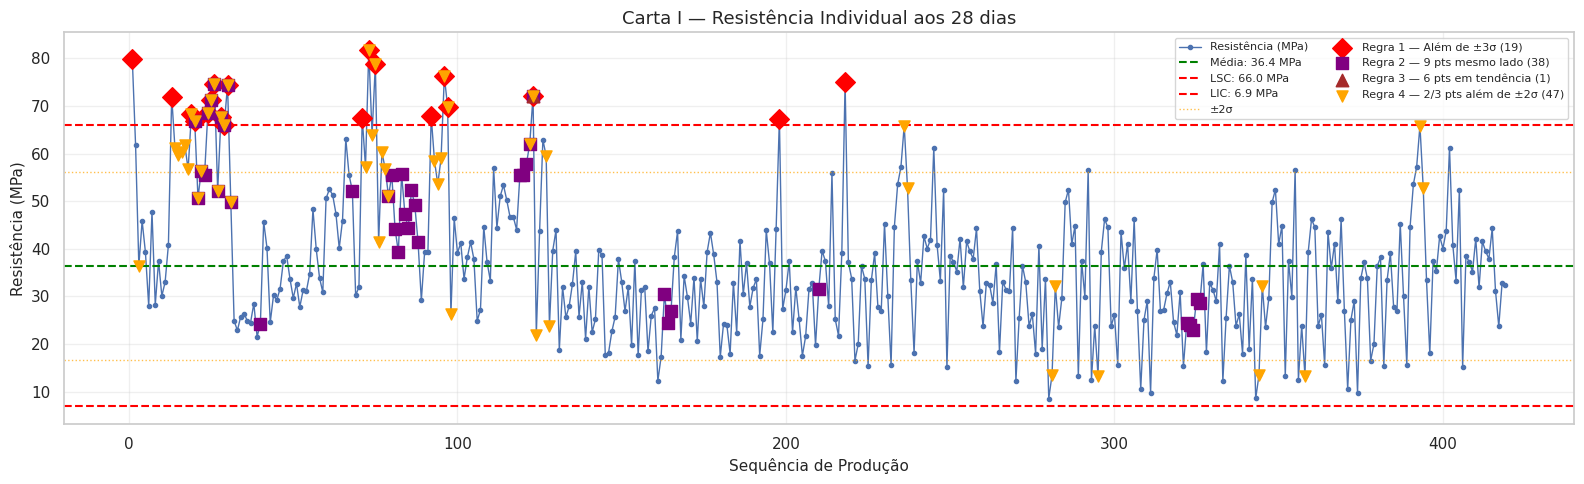

  → Figura salva: carta_I.png


In [ ]:
# BLOCO 9: CARTA I — VALORES INDIVIDUAIS DE RESISTÊNCIA

print("=" * 55)
print("CARTA I — RESISTÊNCIA INDIVIDUAL (28 dias)")
print("=" * 55)

# --- Cálculo dos parâmetros da carta ---
valores = df_28["resistencia"].values
n = len(valores)

media_I = valores.mean()

# Amplitude Móvel (MR): diferença absoluta entre pontos consecutivos
MR = np.abs(np.diff(valores))          # n-1 valores
media_MR = MR.mean()

# Estimativa de σ via amplitude móvel (constante d2 = 1.128 para n=2)
d2 = 1.128
sigma_I = media_MR / d2

# Limites de controle (±3σ)
UCL_I = media_I + 3 * sigma_I
LCL_I = media_I - 3 * sigma_I

print(f"\n  Parâmetros calculados:")
print(f"  Média (X̄):          {media_I:.2f} MPa")
print(f"  Média MR (MR̄):      {media_MR:.2f} MPa")
print(f"  Sigma estimado (σ): {sigma_I:.2f} MPa")
print(f"  LSC (Limite Sup.):  {UCL_I:.2f} MPa")
print(f"  LIC (Limite Inf.):  {LCL_I:.2f} MPa")

# --- Detecção de anomalias ---
anomalias = detectar_todas_regras(valores, media_I, sigma_I, LCL_I, UCL_I)

print(f"\n  Anomalias detectadas:")
total = 0
for regra, indices in anomalias.items():
    print(f"  {regra}: {len(indices)} ocorrência(s)")
    total += len(indices)
print(f"  Total de pontos sinalizados: {total}")

# --- Plotagem ---
fig, ax = plt.subplots(figsize=(16, 5))

# Série principal
ax.plot(range(1, n+1), valores,
        color="#4C72B0", linewidth=1.0,
        marker="o", markersize=3, label="Resistência (MPa)")

# Linhas de referência
ax.axhline(media_I, color="green",   linestyle="--", linewidth=1.5,
           label=f"Média: {media_I:.1f} MPa")
ax.axhline(UCL_I,   color="red",     linestyle="--", linewidth=1.5,
           label=f"LSC: {UCL_I:.1f} MPa")
ax.axhline(LCL_I,   color="red",     linestyle="--", linewidth=1.5,
           label=f"LIC: {LCL_I:.1f} MPa")
ax.axhline(media_I + 2*sigma_I, color="orange", linestyle=":",
           linewidth=1.0, alpha=0.7, label="±2σ")
ax.axhline(media_I - 2*sigma_I, color="orange", linestyle=":",
           linewidth=1.0, alpha=0.7)

# Marcação de anomalias — cores por regra
cores_regras = {
    "Regra 1 — Além de ±3σ":         ("red",    "D", 10),
    "Regra 2 — 9 pts mesmo lado":     ("purple", "s",  9),
    "Regra 3 — 6 pts em tendência":   ("brown",  "^",  9),
    "Regra 4 — 2/3 pts além de ±2σ":  ("orange", "v",  8),
}

for regra, indices in anomalias.items():
    if indices:
        cor, marcador, tamanho = cores_regras[regra]
        ax.scatter([i+1 for i in indices],
                   [valores[i] for i in indices],
                   color=cor, marker=marcador,
                   s=tamanho**2, zorder=5,
                   label=f"{regra} ({len(indices)})")

ax.set_title("Carta I — Resistência Individual aos 28 dias", fontsize=13)
ax.set_xlabel("Sequência de Produção")
ax.set_ylabel("Resistência (MPa)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("carta_I.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: carta_I.png")

CARTA MR — AMPLITUDE MÓVEL

  Parâmetros calculados:
  Média MR (MR̄):     11.11 MPa
  LSC (D4 × MR̄):    36.31 MPa
  LIC:               0.00 MPa (fixo para n=2)

  Pontos além do LSC na Carta MR: 9
  Posições: [75, 97, 123, 198, 218, 248, 292, 355, 405]
    → Ponto 75 com resistência 37.4 MPa está ACIMA do limite de controle (desvio de 26.3 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=451 kg/m³, água=165 kg/m³, a/c=0.37).
    → Ponto 97 com resistência 43.6 MPa está ACIMA do limite de controle (desvio de 32.5 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=500 kg/m³, água=151 kg/m³, a/c=0.30).
    → Ponto 123 com resistência 50.1 MPa está ACIMA do limite de controle (desvio de 39.0 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=424 kg/m³, água=168 kg/m³, a/c=0.40).
    → Ponto 198 com resistência 40.0 MPa está ACIMA do limite de controle (desvio de 28.9 MPa em relaç

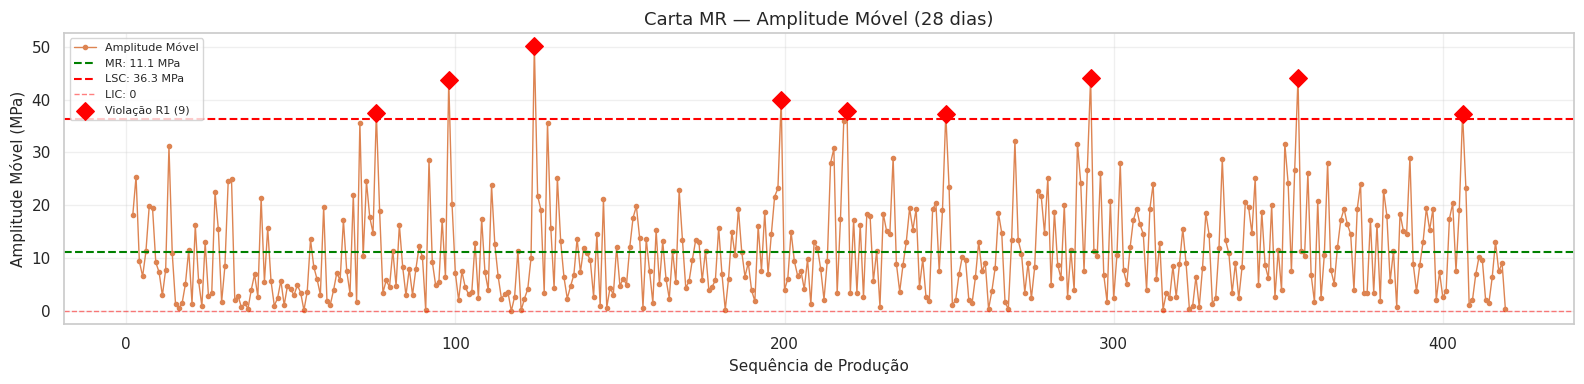

  → Figura salva: carta_MR.png


In [ ]:
# BLOCO 10: CARTA MR — AMPLITUDE MÓVEL
# A Carta MR sempre acompanha a Carta I.
# Ela monitora a variabilidade entre pontos consecutivos.
# Um ponto fora do LSC da MR significa salto brusco no processo.

print("=" * 55)
print("CARTA MR — AMPLITUDE MÓVEL")
print("=" * 55)

# Parâmetros da carta MR
# Constantes para n=2: D3=0 (LIC sempre zero), D4=3.267
D4 = 3.267
UCL_MR = D4 * media_MR
LCL_MR = 0  # Por definição para n=2

print(f"\n  Parâmetros calculados:")
print(f"  Média MR (MR̄):     {media_MR:.2f} MPa")
print(f"  LSC (D4 × MR̄):    {UCL_MR:.2f} MPa")
print(f"  LIC:               {LCL_MR:.2f} MPa (fixo para n=2)")

# Detecção de anomalias na carta MR (apenas Regra 1 é padrão para MR)
pontos_MR = MR.tolist()
violacoes_MR = regra_1(pontos_MR, LCL_MR, UCL_MR)

print(f"\n  Pontos além do LSC na Carta MR: {len(violacoes_MR)}")
if violacoes_MR:
    print(f"  Posições: {[i+1 for i in violacoes_MR]}")
    for idx in violacoes_MR[:5]:  # exibe até 5
        print(f"    → {explicar_anomalia('Regra 1 — Além de ±3σ', idx, pontos_MR, media_MR, df_28)}")

# Plotagem
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(range(2, n+1), MR,
        color="#DD8452", linewidth=1.0,
        marker="o", markersize=3, label="Amplitude Móvel")

ax.axhline(media_MR, color="green",  linestyle="--",
           linewidth=1.5, label=f"MR̄: {media_MR:.1f} MPa")
ax.axhline(UCL_MR,   color="red",    linestyle="--",
           linewidth=1.5, label=f"LSC: {UCL_MR:.1f} MPa")
ax.axhline(LCL_MR,   color="red",    linestyle="--",
           linewidth=1.0, alpha=0.5, label="LIC: 0")

# Marcação de violações
if violacoes_MR:
    ax.scatter([i+2 for i in violacoes_MR],
               [MR[i] for i in violacoes_MR],
               color="red", marker="D", s=80, zorder=5,
               label=f"Violação R1 ({len(violacoes_MR)})")

ax.set_title("Carta MR — Amplitude Móvel (28 dias)", fontsize=13)
ax.set_xlabel("Sequência de Produção")
ax.set_ylabel("Amplitude Móvel (MPa)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("carta_MR.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: carta_MR.png")

In [ ]:
# ============================================================
# BLOCO 11: RELATÓRIO TEXTUAL DAS ANOMALIAS
# ============================================================

print("=" * 55)
print("RELATÓRIO DE ANOMALIAS — CARTA I")
print("=" * 55)

# Contagem geral
total_anomalias = sum(len(v) for v in anomalias.values())
indices_unicos = set()
for indices in anomalias.values():
    indices_unicos.update(indices)

print(f"\n  Total de sinalizações:      {total_anomalias}")
print(f"  Pontos únicos sinalizados:  {len(indices_unicos)}")
print(f"  Pontos sob controle:        {n - len(indices_unicos)}")
print(f"  Taxa de não conformidade:   "
      f"{len(indices_unicos)/n*100:.1f}%")

# Relatório detalhado por regra
for regra, indices in anomalias.items():
    print(f"\n{'─'*55}")
    print(f"  {regra.upper()}")
    print(f"  Ocorrências: {len(indices)}")

    if not indices:
        print("  → Nenhuma violação detectada. ✔")
        continue

    # Mostra até 8 ocorrências para não poluir o output
    for idx in indices[:8]:
        explicacao = explicar_anomalia(regra, idx, valores, media_I, df_28)
        print(f"\n  [Ponto {idx+1}]")
        print(f"  {explicacao}")

    if len(indices) > 8:
        print(f"\n  ... e mais {len(indices)-8} ocorrência(s) não exibidas.")

# Conclusão interpretativa
print(f"\n{'='*55}")
print("  INTERPRETAÇÃO GERAL DO PROCESSO")
print(f"{'='*55}")

pct_fora = len(indices_unicos) / n * 100

if pct_fora == 0:
    status = "PROCESSO SOB CONTROLE ESTATÍSTICO"
    interpretacao = (
        "Nenhuma regra de Nelson foi violada. O processo de "
        "produção de concreto apresenta variabilidade dentro "
        "dos limites esperados."
    )
elif pct_fora <= 5:
    status = "PROCESSO COM INSTABILIDADE LEVE"
    interpretacao = (
        f"{pct_fora:.1f}% dos pontos sinalizados. O processo "
        "apresenta sinais esporádicos de instabilidade. "
        "Recomenda-se investigação pontual das causas."
    )
elif pct_fora <= 15:
    status = "PROCESSO COM INSTABILIDADE MODERADA"
    interpretacao = (
        f"{pct_fora:.1f}% dos pontos sinalizados. O processo "
        "apresenta padrões sistemáticos de instabilidade. "
        "Ação corretiva é necessária antes de análise de capacidade."
    )
else:
    status = "PROCESSO FORA DE CONTROLE"
    interpretacao = (
        f"{pct_fora:.1f}% dos pontos sinalizados. O processo "
        "está estatisticamente fora de controle. A análise de "
        "capacidade (Cp/Cpk) não é válida neste estado."
    )

print(f"\n  Status: {status}")
print(f"\n  {interpretacao}")
print(f"\n  Próximo passo: Parte 3 — Análise de Capacidade do Processo")

RELATÓRIO DE ANOMALIAS — CARTA I

  Total de sinalizações:      105
  Pontos únicos sinalizados:  77
  Pontos sob controle:        342
  Taxa de não conformidade:   18.4%

───────────────────────────────────────────────────────
  REGRA 1 — ALÉM DE ±3Σ
  Ocorrências: 19

  [Ponto 1]
  Ponto 1 com resistência 80.0 MPa está ACIMA do limite de controle (desvio de 43.6 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=540 kg/m³, água=162 kg/m³, a/c=0.30).

  [Ponto 13]
  Ponto 13 com resistência 72.0 MPa está ACIMA do limite de controle (desvio de 35.6 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=485 kg/m³, água=146 kg/m³, a/c=0.30).

  [Ponto 19]
  Ponto 19 com resistência 68.3 MPa está ACIMA do limite de controle (desvio de 31.9 MPa em relação à média). Causa possível: variação extrema em insumos críticos (cimento=475 kg/m³, água=181 kg/m³, a/c=0.38).

  [Ponto 20]
  Ponto 20 com resistência 66.9 MPa está ACIMA

ANÁLISE DE CAPACIDADE DO PROCESSO

  Limites de especificação adotados:
  LIE (mínimo estrutural): 20.0 MPa
  LSE (máximo prático):    80.0 MPa

  Resultados:
  Índice      Valor  Interpretação
  --------------------------------------------------
  Cp          1.015  Marginalmente capaz
  Cpu         1.474  Adequado (padrão mínimo industrial)
  Cpl         0.556  INCAPAZ — processo fora de especificação
  Cpk         0.556  INCAPAZ — processo fora de especificação

  % esperado fora de especificação: 4.7728%


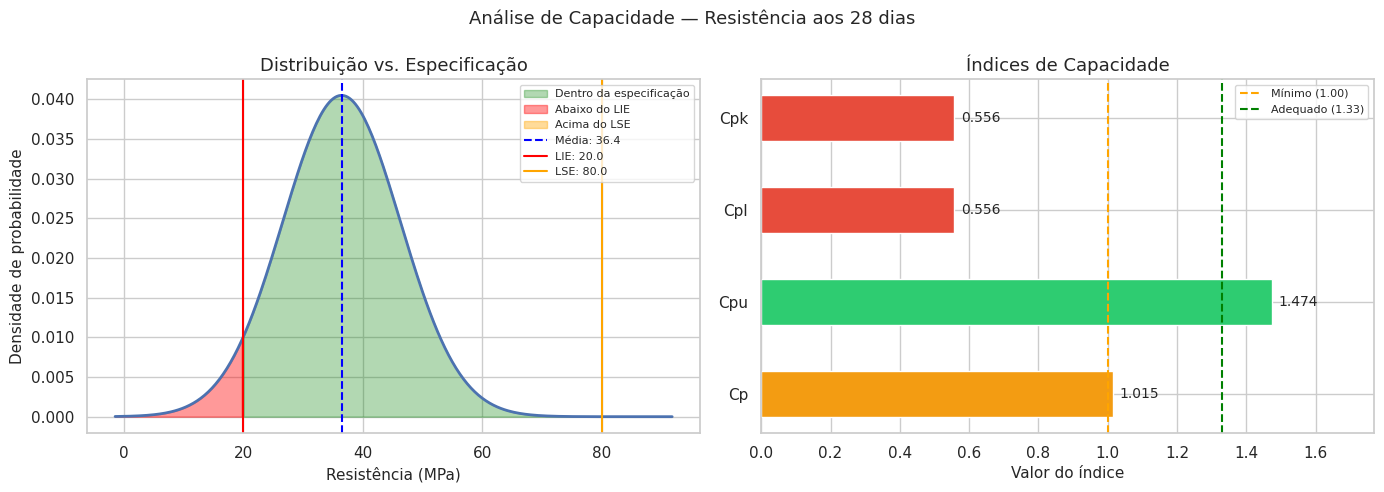


  → Figura salva: capacidade.png

  CONCLUSÃO: Cpk = 0.556 — INCAPAZ — processo fora de especificação


In [ ]:
# BLOCO 12: ANÁLISE DE CAPACIDADE DO PROCESSO (Cp e Cpk)
# A análise de capacidade responde: "O processo é capaz de
# atender às especificações técnicas?"
# Para concreto, usamos a norma ABNT NBR 12655 como referência.

print("=" * 55)
print("ANÁLISE DE CAPACIDADE DO PROCESSO")
print("=" * 55)

# --- Limites de especificação (norma ABNT NBR 12655) ---
# LSE: Limite Superior de Especificação (sem limite prático superior)
# LIE: Limite Inferior de Especificação
# Para concreto de uso geral, o mínimo aceitável é fck = 20 MPa
# Para alta resistência (nosso limiar), usamos 40 MPa como LIE

LIE = 20.0   # MPa — mínimo absoluto para estruturas (NBR 12655)
LSE = 80.0   # MPa — limite prático superior do dataset

print(f"\n  Limites de especificação adotados:")
print(f"  LIE (mínimo estrutural): {LIE} MPa")
print(f"  LSE (máximo prático):    {LSE} MPa")

# --- Cálculo dos índices ---
# sigma_I já foi calculado no Bloco 9 via amplitude móvel
# Usamos sigma_I para consistência com as cartas de controle

Cp  = (LSE - LIE) / (6 * sigma_I)
Cpu = (LSE - media_I) / (3 * sigma_I)   # capacidade superior
Cpl = (media_I - LIE) / (3 * sigma_I)   # capacidade inferior
Cpk = min(Cpu, Cpl)                       # índice real (pior lado)

# Percentual esperado fora de especificação (via distribuição normal)
z_superior = (LSE - media_I) / sigma_I
z_inferior = (media_I - LIE) / sigma_I
pct_fora_esp = (stats.norm.cdf(-z_inferior) +
                (1 - stats.norm.cdf(z_superior))) * 100

print(f"\n  Resultados:")
print(f"  {'Índice':<8} {'Valor':>8}  {'Interpretação'}")
print(f"  {'-'*50}")

def interpretar_cp(valor):
    if valor >= 1.67:
        return "Excelente (Seis Sigma)"
    elif valor >= 1.33:
        return "Adequado (padrão mínimo industrial)"
    elif valor >= 1.00:
        return "Marginalmente capaz"
    else:
        return "INCAPAZ — processo fora de especificação"

for nome, val in [("Cp", Cp), ("Cpu", Cpu), ("Cpl", Cpl), ("Cpk", Cpk)]:
    print(f"  {nome:<8} {val:>8.3f}  {interpretar_cp(val)}")

print(f"\n  % esperado fora de especificação: {pct_fora_esp:.4f}%")

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: distribuição com limites
x_range = np.linspace(valores.min() - 10, valores.max() + 10, 300)
y_norm  = stats.norm.pdf(x_range, media_I, sigma_I)

axes[0].plot(x_range, y_norm, color="#4C72B0", linewidth=2)
axes[0].fill_between(x_range, y_norm,
                     where=(x_range >= LIE) & (x_range <= LSE),
                     alpha=0.3, color="green", label="Dentro da especificação")
axes[0].fill_between(x_range, y_norm,
                     where=(x_range < LIE),
                     alpha=0.4, color="red", label="Abaixo do LIE")
axes[0].fill_between(x_range, y_norm,
                     where=(x_range > LSE),
                     alpha=0.4, color="orange", label="Acima do LSE")

axes[0].axvline(media_I, color="blue",  linestyle="--",
                linewidth=1.5, label=f"Média: {media_I:.1f}")
axes[0].axvline(LIE,     color="red",   linestyle="-",
                linewidth=1.5, label=f"LIE: {LIE}")
axes[0].axvline(LSE,     color="orange",linestyle="-",
                linewidth=1.5, label=f"LSE: {LSE}")

axes[0].set_title("Distribuição vs. Especificação")
axes[0].set_xlabel("Resistência (MPa)")
axes[0].set_ylabel("Densidade de probabilidade")
axes[0].legend(fontsize=8)

# Gráfico 2: gauge visual dos índices
indices_nomes  = ["Cp", "Cpu", "Cpl", "Cpk"]
indices_valores = [Cp, Cpu, Cpl, Cpk]
cores_gauge = ["#2ecc71" if v >= 1.33 else
               "#f39c12" if v >= 1.00 else
               "#e74c3c" for v in indices_valores]

bars = axes[1].barh(indices_nomes, indices_valores,
                    color=cores_gauge, edgecolor="white", height=0.5)
axes[1].axvline(1.00, color="orange", linestyle="--",
                linewidth=1.5, label="Mínimo (1.00)")
axes[1].axvline(1.33, color="green",  linestyle="--",
                linewidth=1.5, label="Adequado (1.33)")

for bar, val in zip(bars, indices_valores):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=10)

axes[1].set_title("Índices de Capacidade")
axes[1].set_xlabel("Valor do índice")
axes[1].set_xlim(0, max(indices_valores) * 1.2)
axes[1].legend(fontsize=8)

plt.suptitle("Análise de Capacidade — Resistência aos 28 dias", fontsize=13)
plt.tight_layout()
plt.savefig("capacidade.png", bbox_inches="tight")
plt.show()

print("\n  → Figura salva: capacidade.png")
print(f"\n  CONCLUSÃO: Cpk = {Cpk:.3f} — {interpretar_cp(Cpk)}")

In [ ]:
# BLOCO 13: MODELOS PARA IDENTIFICAR VARIÁVEIS DISCREPANTES
# Objetivo: usar ML não só para classificar, mas para entender
# QUAIS variáveis causam as oscilações detectadas nas cartas.

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print("=" * 55)
print("MODELOS — IDENTIFICAÇÃO DE VARIÁVEIS DISCREPANTES")
print("=" * 55)

# --- Preparação ---
# Usamos o dataset completo (df) para treinar os modelos
# A variável alvo é 'categoria' (0 = comum, 1 = alta resistência)

features = ["cimento", "escoria", "cinza_volante", "agua",
            "superplastificante", "agregado_graudo",
            "agregado_miudo", "idade"]

X = df[features]
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n  Amostras de treino: {len(X_train)}")
print(f"  Amostras de teste:  {len(X_test)}")

# --- Modelos ---
modelos = {
    "Árvore de Decisão":      DecisionTreeClassifier(max_depth=5,
                                                      random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=100,
                                                      random_state=42),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=100,
                                                          random_state=42),
    "Regressão Logística":    LogisticRegression(max_iter=1000,
                                                  random_state=42),
}

resultados = {}

print(f"\n  {'Modelo':<25} {'Acurácia Treino':>16} "
      f"{'Acurácia Teste':>15} {'CV (5-fold)':>12}")
print("  " + "-" * 72)

for nome, modelo in modelos.items():
    # Regressão Logística usa dados escalonados
    if "Logística" in nome:
        modelo.fit(X_train_sc, y_train)
        pred = modelo.predict(X_test_sc)
        acc_train = modelo.score(X_train_sc, y_train)
        cv = cross_val_score(modelo, X_train_sc, y_train,
                             cv=5, scoring="accuracy")
    else:
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        acc_train = modelo.score(X_train, y_train)
        cv = cross_val_score(modelo, X_train, y_train,
                             cv=5, scoring="accuracy")

    acc_test = accuracy_score(y_test, pred)
    resultados[nome] = {
        "modelo": modelo,
        "pred":   pred,
        "acc_train": acc_train,
        "acc_test":  acc_test,
        "cv_mean":   cv.mean(),
        "cv_std":    cv.std(),
    }

    print(f"  {nome:<25} {acc_train:>15.2%} "
          f"{acc_test:>15.2%} {cv.mean():>10.2%}±{cv.std():.2%}")

MODELOS — IDENTIFICAÇÃO DE VARIÁVEIS DISCREPANTES

  Amostras de treino: 703
  Amostras de teste:  302

  Modelo                     Acurácia Treino  Acurácia Teste  CV (5-fold)
  ------------------------------------------------------------------------
  Árvore de Decisão                  91.61%          85.10%     83.64%±1.19%
  Random Forest                      99.86%          90.07%     88.48%±3.82%
  Gradient Boosting                  97.87%          91.72%     88.76%±4.70%
  Regressão Logística                81.22%          80.79%     80.08%±4.42%


IMPORTÂNCIA DAS VARIÁVEIS — CAUSA RAIZ

  Variáveis por ordem de impacto na resistência:
  Variável                Importância   Acumulado
  ------------------------------------------------
  idade                        0.285      28.5%  ██████████████
  cimento                      0.191      47.6%  █████████
  agua                         0.128      60.4%  ██████
  superplastificante           0.101      70.5%  █████
  agregado_miudo               0.090      79.5%  ████
  agregado_graudo              0.081      87.5%  ████
  escoria                      0.070      94.5%  ███
  cinza_volante                0.055     100.0%  ██

  Importância comparada (todos os modelos com feature importance):


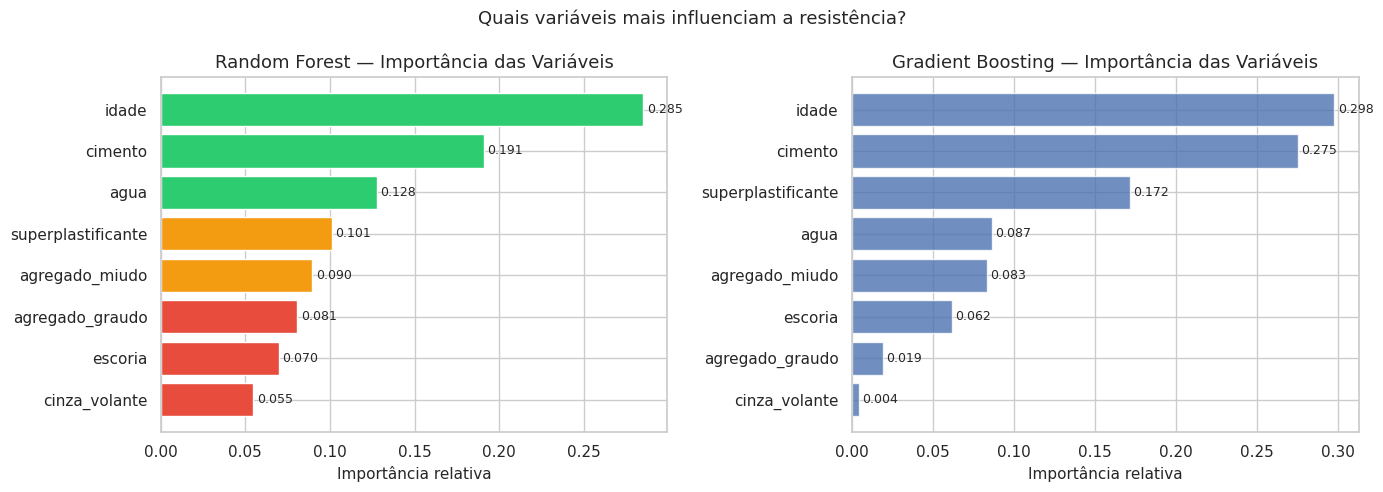

  → Figura salva: importancia_variaveis.png


In [ ]:
# BLOCO 14: IMPORTÂNCIA DAS VARIÁVEIS (CAUSA RAIZ)

print("=" * 55)
print("IMPORTÂNCIA DAS VARIÁVEIS — CAUSA RAIZ")
print("=" * 55)

# Random Forest como modelo principal para feature importance
# (mais estável que Árvore simples, mais interpretável que Boosting)
rf = resultados["Random Forest"]["modelo"]
importancias = pd.Series(rf.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=False)

print("\n  Variáveis por ordem de impacto na resistência:")
print(f"  {'Variável':<22} {'Importância':>12}  {'Acumulado':>10}")
print("  " + "-" * 48)
acumulado = 0
for var, imp in importancias.items():
    acumulado += imp
    barra = "█" * int(imp * 50)
    print(f"  {var:<22} {imp:>11.3f}  {acumulado:>9.1%}  {barra}")

# --- Comparação entre modelos ---
print("\n  Importância comparada (todos os modelos com feature importance):")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Random Forest
cores_imp = ["#2ecc71" if i < 3 else
             "#f39c12" if i < 5 else
             "#e74c3c" for i in range(len(importancias))]

axes[0].barh(importancias.index[::-1],
             importancias.values[::-1],
             color=cores_imp[::-1], edgecolor="white")
axes[0].set_title("Random Forest — Importância das Variáveis")
axes[0].set_xlabel("Importância relativa")
for i, (var, val) in enumerate(zip(importancias.index[::-1],
                                    importancias.values[::-1])):
    axes[0].text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)

# Gráfico 2: Gradient Boosting para comparação
gb = resultados["Gradient Boosting"]["modelo"]
imp_gb = pd.Series(gb.feature_importances_, index=features)
imp_gb = imp_gb.sort_values(ascending=False)

axes[1].barh(imp_gb.index[::-1],
             imp_gb.values[::-1],
             color="#4C72B0", alpha=0.8, edgecolor="white")
axes[1].set_title("Gradient Boosting — Importância das Variáveis")
axes[1].set_xlabel("Importância relativa")
for i, (var, val) in enumerate(zip(imp_gb.index[::-1],
                                    imp_gb.values[::-1])):
    axes[1].text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Quais variáveis mais influenciam a resistência?", fontsize=13)
plt.tight_layout()
plt.savefig("importancia_variaveis.png", bbox_inches="tight")
plt.show()
print("  → Figura salva: importancia_variaveis.png")

ANÁLISE DE CENÁRIOS — SIMULAÇÃO DE VARIÁVEIS

  Cenário base (medianas do dataset):
  cimento               : 265.0
  escoria               : 20.0
  cinza_volante         : 0.0
  agua                  : 185.7
  superplastificante    : 6.1
  agregado_graudo       : 968.0
  agregado_miudo        : 780.0
  idade                 : 28.0

  Top 3 variáveis analisadas: ['idade', 'cimento', 'agua']

  idade — impacto na probabilidade de alta resistência:
  idade = 16.8 (-40%) → P(Alta Res.) = 21.0%
  idade = 22.4 (-20%) → P(Alta Res.) = 32.0%
  idade = 28.0 (+0%) → P(Alta Res.) = 32.0%
  idade = 33.6 (+20%) → P(Alta Res.) = 33.0%
  idade = 39.2 (+40%) → P(Alta Res.) = 33.0%

  cimento — impacto na probabilidade de alta resistência:
  cimento = 159.0 (-40%) → P(Alta Res.) = 10.0%
  cimento = 212.0 (-20%) → P(Alta Res.) = 15.0%
  cimento = 265.0 (+0%) → P(Alta Res.) = 32.0%
  cimento = 318.0 (+20%) → P(Alta Res.) = 57.0%
  cimento = 371.0 (+40%) → P(Alta Res.) = 60.0%

  agua — impacto na probab

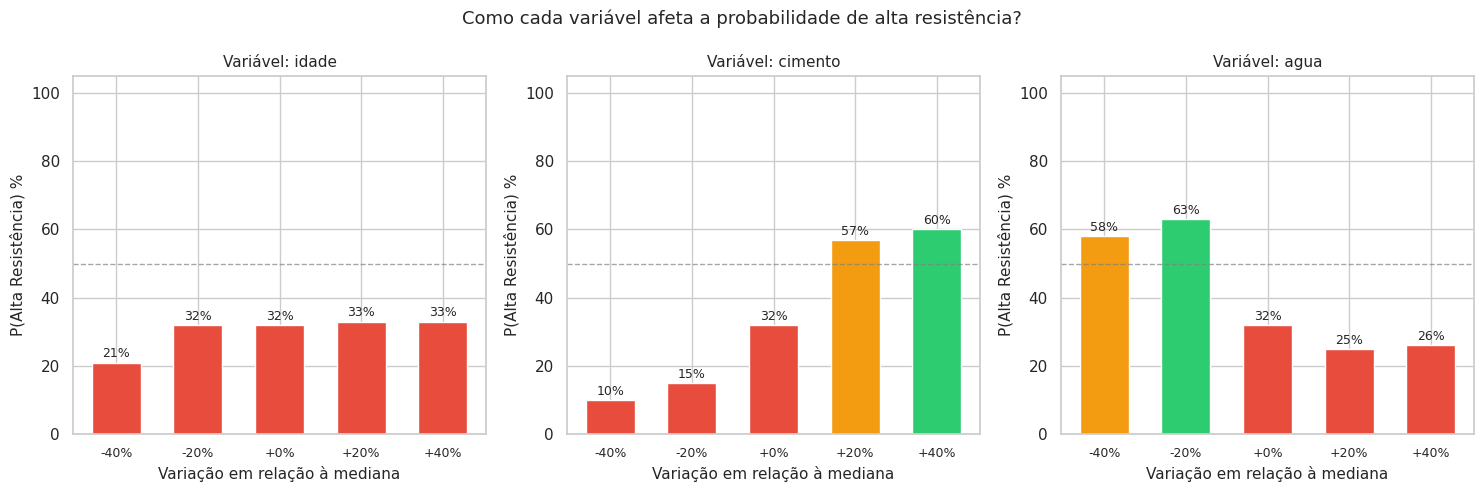


  → Figura salva: cenarios.png


In [ ]:
# BLOCO 15: ANÁLISE DE CENÁRIOS — VARIÁVEIS DISCREPANTES
# Simulamos variações nas variáveis mais importantes e vemos
# como isso afeta a probabilidade de alta resistência.

print("=" * 55)
print("ANÁLISE DE CENÁRIOS — SIMULAÇÃO DE VARIÁVEIS")
print("=" * 55)

# Usamos a mediana do dataset como ponto de partida (cenário base)
cenario_base = df[features].median().to_dict()

print("\n  Cenário base (medianas do dataset):")
for k, v in cenario_base.items():
    print(f"  {k:<22}: {v:.1f}")

# Pegamos as 3 variáveis mais importantes do Random Forest
top3 = importancias.index[:3].tolist()
print(f"\n  Top 3 variáveis analisadas: {top3}")

# Para cada variável do top3, simulamos 5 níveis (±20%, ±10%, base)
rf_model = resultados["Random Forest"]["modelo"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, variavel in zip(axes, top3):
    val_base   = cenario_base[variavel]
    niveis     = [val_base * f for f in [0.60, 0.80, 1.00, 1.20, 1.40]]
    probs_alta = []

    for nivel in niveis:
        cenario = cenario_base.copy()
        cenario[variavel] = nivel
        X_sim = pd.DataFrame([cenario])[features]
        prob  = rf_model.predict_proba(X_sim)[0][1]  # prob. classe 1
        probs_alta.append(prob * 100)

    # Plotagem
    variacao_pct = [(n/val_base - 1)*100 for n in niveis]
    cores_bar = ["#e74c3c" if p < 40 else
                 "#f39c12" if p < 60 else
                 "#2ecc71" for p in probs_alta]

    bars = ax.bar(range(len(niveis)), probs_alta,
                  color=cores_bar, edgecolor="white", width=0.6)

    ax.set_xticks(range(len(niveis)))
    ax.set_xticklabels([f"{v:+.0f}%" for v in variacao_pct], fontsize=9)
    ax.axhline(50, color="gray", linestyle="--",
               linewidth=1, alpha=0.7, label="Limiar 50%")
    ax.set_ylim(0, 105)
    ax.set_title(f"Variável: {variavel}", fontsize=11)
    ax.set_xlabel("Variação em relação à mediana")
    ax.set_ylabel("P(Alta Resistência) %")

    for bar, prob in zip(bars, probs_alta):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f"{prob:.0f}%", ha="center", fontsize=9)

    print(f"\n  {variavel} — impacto na probabilidade de alta resistência:")
    for nivel, prob, var_pct in zip(niveis, probs_alta, variacao_pct):
        print(f"  {variavel} = {nivel:.1f} ({var_pct:+.0f}%) → "
              f"P(Alta Res.) = {prob:.1f}%")

plt.suptitle("Como cada variável afeta a probabilidade de alta resistência?",
             fontsize=13)
plt.tight_layout()
plt.savefig("cenarios.png", bbox_inches="tight")
plt.show()
print("\n  → Figura salva: cenarios.png")

In [ ]:
# ============================================================
# BLOCO 16: RELATÓRIO FINAL CONSOLIDADO
# ============================================================

separador = "=" * 60

print(separador)
print("  RELATÓRIO FINAL — CONTROLE ESTATÍSTICO DE PROCESSOS")
print("  Dataset: Resistência à Compressão do Concreto (UCI)")
print(separador)

# --- SEÇÃO 1: DADOS ---
print(f"\n{'─'*60}")
print("  1. CARACTERIZAÇÃO DO DATASET")
print(f"{'─'*60}")
print(f"  Registros analisados:       {len(df)}")
print(f"  Duplicatas removidas:       {len(df_raw) - len(df)}")
print(f"  Amostras aos 28 dias:       {len(df_28)}")
print(f"  Variáveis de processo:      {len(features)}")
print(f"  Período de cura analisado:  28 dias (ABNT NBR 5739)")

# --- SEÇÃO 2: ESTATÍSTICAS ---
print(f"\n{'─'*60}")
print("  2. ESTATÍSTICAS DA RESISTÊNCIA (28 DIAS)")
print(f"{'─'*60}")
print(f"  Média:              {media_I:.2f} MPa")
print(f"  Desvio padrão (σ):  {sigma_I:.2f} MPa")
print(f"  Mínimo:             {valores.min():.2f} MPa")
print(f"  Máximo:             {valores.max():.2f} MPa")
print(f"  CV%:                {sigma_I/media_I*100:.1f}%")

# --- SEÇÃO 3: CARTAS DE CONTROLE ---
print(f"\n{'─'*60}")
print("  3. CARTAS DE CONTROLE — RESULTADOS")
print(f"{'─'*60}")

total_anomalias = sum(len(v) for v in anomalias.items())
unicos = set()
for indices in anomalias.values():
    unicos.update(indices)

print(f"  LSC Carta I:                {UCL_I:.2f} MPa")
print(f"  LIC Carta I:                {LCL_I:.2f} MPa")
print(f"  Pontos sinalizados:         {len(unicos)} de {n} "
      f"({len(unicos)/n*100:.1f}%)")

for regra, indices in anomalias.items():
    status_reg = "✔" if len(indices) == 0 else "⚠"
    print(f"  {status_reg} {regra}: {len(indices)} ocorrência(s)")

# Interpretação automática do status
pct = len(unicos) / n * 100
if pct == 0:
    status_processo = "SOB CONTROLE"
elif pct <= 5:
    status_processo = "INSTABILIDADE LEVE"
elif pct <= 15:
    status_processo = "INSTABILIDADE MODERADA"
else:
    status_processo = "FORA DE CONTROLE"

print(f"\n  STATUS DO PROCESSO: {status_processo}")

# --- SEÇÃO 4: CAPACIDADE ---
print(f"\n{'─'*60}")
print("  4. CAPACIDADE DO PROCESSO")
print(f"{'─'*60}")
print(f"  LIE (especificação):  {LIE} MPa")
print(f"  LSE (especificação):  {LSE} MPa")
print(f"  Cp:   {Cp:.3f}  — {interpretar_cp(Cp)}")
print(f"  Cpk:  {Cpk:.3f}  — {interpretar_cp(Cpk)}")
print(f"  % esperado fora:      {pct_fora_esp:.4f}%")

# --- SEÇÃO 5: VARIÁVEIS DISCREPANTES ---
print(f"\n{'─'*60}")
print("  5. VARIÁVEIS QUE MAIS INFLUENCIAM A RESISTÊNCIA")
print(f"{'─'*60}")
print(f"  (Baseado no modelo Random Forest — "
      f"Acurácia: {resultados['Random Forest']['acc_test']:.1%})\n")

for i, (var, imp) in enumerate(importancias.items(), 1):
    nivel = "ALTA" if i <= 3 else ("MÉDIA" if i <= 5 else "BAIXA")
    print(f"  {i}º {var:<22} Importância: {imp:.3f}  [{nivel}]")

# --- SEÇÃO 6: CAUSAS DAS OSCILAÇÕES ---
print(f"\n{'─'*60}")
print("  6. CAUSAS PROVÁVEIS DAS OSCILAÇÕES DETECTADAS")
print(f"{'─'*60}")

# Texto interpretativo baseado nas variáveis do top3
top1, top2, top3_var = importancias.index[0], importancias.index[1], importancias.index[2]

causas = {
    "cimento": (
        "Variação na dosagem de cimento é a principal causa de "
        "oscilação. Erro de 10% na dosagem pode deslocar a "
        "resistência em até 5 MPa. Verificar calibração das balanças "
        "e consistência dos lotes de fornecimento."
    ),
    "agua": (
        "A relação água/cimento é o fator mais sensível na hidratação. "
        "Pequenas variações na umidade dos agregados ou no volume de "
        "água adicionado impactam diretamente a resistência final."
    ),
    "idade": (
        "A variação de idade nas amostras introduz variabilidade "
        "sistemática. Ensaios misturados de diferentes idades "
        "devem ser analisados separadamente."
    ),
    "escoria": (
        "Escória de alto-forno afeta a resistência tardia. "
        "Variações no teor de escória impactam principalmente "
        "resistências acima de 28 dias."
    ),
    "cinza_volante": (
        "Cinza volante contribui para resistência a longo prazo. "
        "Sua variação indica inconsistência nos materiais "
        "cimentícios suplementares."
    ),
    "superplastificante": (
        "Variação no teor de aditivo afeta a trabalhabilidade e "
        "pode indicar dosagem incorreta ou lote diferente "
        "de produto."
    ),
    "agregado_graudo": (
        "Variação granulométrica do agregado graúdo afeta o "
        "empacotamento e a interface pasta-agregado."
    ),
    "agregado_miudo": (
        "Variação no módulo de finura da areia altera a "
        "demanda de água e pode mascarar outros efeitos."
    ),
}

for var in [top1, top2, top3_var]:
    texto = causas.get(var, f"Variável {var} identificada como relevante.")
    print(f"\n  [{var.upper()}]")
    print(f"  {texto}")

# --- SEÇÃO 7: RECOMENDAÇÕES ---
print(f"\n{'─'*60}")
print("  7. RECOMENDAÇÕES")
print(f"{'─'*60}")

recomendacoes = [
    (f"Monitorar {top1} e {top2} com amostragem aumentada",
     "São as variáveis de maior impacto. Reduzir o intervalo "
     "de coleta de 1 por lote para 3 por turno."),
    ("Investigar pontos fora de controle da Carta I",
     f"Os {len(unicos)} pontos sinalizados devem ser rastreados "
     "nos registros de produção para identificar causas especiais."),
    ("Revisar procedimento de dosagem de água",
     "Implementar controle de umidade dos agregados antes da "
     "mistura para reduzir variabilidade da relação a/c."),
    ("Reavaliar limites de especificação",
     f"Com Cpk = {Cpk:.2f}, o processo está "
     f"{'capaz' if Cpk >= 1.33 else 'no limite ou incapaz'}. "
     "Revisar fck de projeto e margens de segurança."),
]

for i, (titulo, detalhe) in enumerate(recomendacoes, 1):
    print(f"\n  {i}. {titulo}")
    print(f"     {detalhe}")

print(f"\n{separador}")
print("  FIM DO RELATÓRIO")
print(separador)

  RELATÓRIO FINAL — CONTROLE ESTATÍSTICO DE PROCESSOS
  Dataset: Resistência à Compressão do Concreto (UCI)

────────────────────────────────────────────────────────────
  1. CARACTERIZAÇÃO DO DATASET
────────────────────────────────────────────────────────────
  Registros analisados:       1005
  Duplicatas removidas:       25
  Amostras aos 28 dias:       419
  Variáveis de processo:      8
  Período de cura analisado:  28 dias (ABNT NBR 5739)

────────────────────────────────────────────────────────────
  2. ESTATÍSTICAS DA RESISTÊNCIA (28 DIAS)
────────────────────────────────────────────────────────────
  Média:              36.43 MPa
  Desvio padrão (σ):  9.85 MPa
  Mínimo:             8.54 MPa
  Máximo:             81.75 MPa
  CV%:                27.0%

────────────────────────────────────────────────────────────
  3. CARTAS DE CONTROLE — RESULTADOS
────────────────────────────────────────────────────────────
  LSC Carta I:                65.99 MPa
  LIC Carta I:                